# Prototype V0.1 - Lightweight & Green Blockchain-AI Supply Chain Framework

**Research title:** A Lightweight and Green Blockchain--AI Framework for Secure and
Energy-Efficient Supply Chain Management

This notebook demonstrates the complete V0.1 workflow:

1. Load data (Kaggle DataCo dataset, or local cache, or synthetic fallback)
2. Inspect dataset
3. Preprocess data
4. Select initial features
5. Train Isolation Forest
6. Generate anomaly results
7. Convert selected records into transactions
8. Create blocks / build blockchain
9. Verify blockchain
10. Simulate tampering
11. Detect tampering
12. Measure execution time
13. Display CPU/memory information
14. Estimate energy (clearly labelled as an estimate)
15. Save results

> Every computational step is delegated to `src/`. This notebook contains no
> re-implementation of the framework logic.


## 0. Setup

The notebook is executed from the repository root. A small bootstrap makes the
`src/` package importable regardless of where the kernel was started.


In [1]:
import sys
from pathlib import Path

def _find_project_root(start: Path = Path.cwd()) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir():
            return candidate
    return start

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)


Project root: e:\PhD-Blockchain-AI


In [3]:
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil

from src.config import (
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    MODELS_DIR,
    RESULTS_DIR,
    DEFAULT_MODEL_FILE,
    DEFAULT_RESULTS_FILE,
    GLOBAL_SEED,
    DATA_SOURCE,
    ANOMALY_TRAIN_FRACTION,
)
from src.logging_config import setup_logging

setup_logging()

from src.data.generator import generate_supply_chain_dataset
from src.data.loading import load_supply_chain_data, download_kaggle_dataset, normalize_kaggle_supply_chain
from src.preprocessing.preprocessing import preprocess_supply_chain_data
from src.preprocessing.feature_engineering import build_feature_matrix, select_features, BASE_FEATURES
from src.ai.anomaly_detection import IsolationForestAnomalyDetector, report_anomaly_metrics
from src.blockchain.core import (
    create_transaction,
    create_block,
    create_genesis_block,
    build_chain_from_transactions,
)
from src.blockchain.crypto import calculate_transaction_hash, calculate_block_hash
from src.blockchain.validation import (
    validate_transaction,
    validate_block,
    verify_chain,
    detect_tampering,
)
from src.security.integrity import modify_transaction_after_sealing
from src.energy.measurement import ExecutionTimer, report_system_info
from src.energy.estimation import estimate_energy_consumption
from src.evaluation.reporting import save_experiment_results
from src.pipeline import load_or_download_dataset, prepare_features, build_blockchain_from_flags

print("Fixed global seed:", GLOBAL_SEED, "| data_source:", DATA_SOURCE)


Fixed global seed: 42 | data_source: auto


## 1. Load data

V0.1 uses a **source-aware loader** (`src/data/loading.py`). With the default
`DATA_SOURCE="auto"` the resolution order is:

1. **local** - reuse `data/raw/supply_chain_raw.csv` if it already exists;
2. **kaggle** - otherwise download the real *DataCo SMART Supply-Chain* dataset
   (`shashwatwork/dataco-smart-supply-chain-for-big-data-analysis`,
   `DataCoSupplyChainDataset.csv`, ~180k rows) via `kagglehub` and cache the
   normalised table to `data/raw/` for offline reuse;
3. **synthetic** - if the download fails (no network / no Kaggle credentials)
   fall back to the deterministic synthetic generator with a warning.

> Kaggle access: public datasets may download anonymously. If a consent prompt
> appears, export `KAGGLE_API_TOKEN` (or place `kaggle.json` in `~/.kaggle/`).


In [4]:
RAW_PATH = RAW_DATA_DIR / "supply_chain_raw.csv"
raw_df, source_used = load_or_download_dataset(RAW_PATH, source="auto", synthetic_n_rows=2000)
print("Source used:", source_used, "| rows:", len(raw_df))
raw_df.head()


e:\PhD-Blockchain-AI\.venv-win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-05 15:12:05,513 | INFO | src.data.loading | Downloading shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv from Kaggle ...


100%|██████████| 17.8M/17.8M [00:07<00:00, 2.54MB/s]
2026-09-05 15:12:15,507 | WARNING | src.data.loading | Kaggle download failed (Error reading file: Error tokenizing data. C error: Buffer overflow caught - possible malformed input file.
). Falling back to the synthetic generator.
2026-09-05 15:12:15,508 | WARNING | src.data.loading | No local/Kaggle dataset; generating synthetic data (source=auto).
2026-09-05 15:12:15,535 | INFO | src.data.generator | Wrote synthetic dataset (2000 rows) to E:\PhD-Blockchain-AI\data\raw\supply_chain_raw.csv


Source used: synthetic | rows: 2000


,transaction_id,participant_id,product_id,order_id,timestamp,quantity,unit_price,total_amount,shipping_days,location_region,transaction_status,known_anomaly,anomaly_type
0,TXN-000001,supplier_a,PROD-052,ORD-000001,2024-11-03 14:19:55.368280,100.0,290.658726,29065.872635,1.163480,APAC,in_transit,0,none
1,TXN-000002,wholesaler_1,PROD-003,ORD-000002,2024-06-11 22:22:19.024244,200.0,434.109523,86821.904540,4.401063,AMER,completed,0,none
2,TXN-000003,distributor_1,PROD-023,ORD-000003,2024-12-13 20:03:44.694959,20.0,496.896383,9937.927653,2.932154,MENA,completed,0,none
3,TXN-000004,manufacturer_1,PROD-027,ORD-000004,2024-08-25 12:57:38.181338,25.0,356.338199,8908.454977,4.645092,APAC,completed,0,none
4,TXN-000005,manufacturer_1,PROD-047,ORD-000005,2024-02-12 07:16:26.616707,500.0,387.255454,193627.726814,5.308485,APAC,completed,0,none


## 2. Inspect dataset

> **Label caveat:** two label kinds may exist depending on the data source:
>
> - `known_anomaly` – *synthetic/controlled* anomalies injected by the generator;
> - `natural_label` – the real `Late_delivery_risk` flag (0/1) inside the DataCo
>   Kaggle table (a delivery-risk annotation, not a security label).
>
> **Neither is a cybersecurity attack label.**


In [5]:
print("Columns:", list(raw_df.columns))
print("Dtypes:\n", raw_df.dtypes.to_string())


Columns: ['transaction_id', 'participant_id', 'product_id', 'order_id', 'timestamp', 'quantity', 'unit_price', 'total_amount', 'shipping_days', 'location_region', 'transaction_status', 'known_anomaly', 'anomaly_type']
Dtypes:
 transaction_id                object
participant_id                object
product_id                    object
order_id                      object
timestamp             datetime64[ns]
quantity                     float64
unit_price                   float64
total_amount                 float64
shipping_days                float64
location_region               object
transaction_status            object
known_anomaly                  int64
anomaly_type                     str


In [6]:
raw_df["transaction_status"].value_counts()


transaction_status
completed     1192
pending        255
in_transit     207
cancelled      188
delayed        158
Name: count, dtype: int64

In [7]:
if "known_anomaly" in raw_df.columns:
    display(raw_df["known_anomaly"].value_counts().rename_axis("label").rename("count").to_frame())
if "natural_label" in raw_df.columns:
    print("natural_label (Late_delivery_risk) distribution:")
    display(raw_df["natural_label"].value_counts().rename_axis("label").rename("count").to_frame())
if "anomaly_type" in raw_df.columns:
    display(raw_df["anomaly_type"].value_counts())


,count
label,
0,1946
3,20
1,17
2,17


anomaly_type
none                1946
delayed_shipment      20
quantity_outlier      17
price_outlier         17
Name: count, dtype: int64

## 3. Preprocess data

Cleaning is deterministic: duplicate transactions removed, missing/non-positive
values dropped, dtypes canonicalised (see `src/preprocessing/preprocessing.py`).
The processed frame is persisted to `data/processed/`.

If the cleaned table is larger than `PROCESS_MAX_ROWS` (the full Kaggle table
is ~180k rows), a fixed-seed sample is used for the feature-engineering stage.


In [8]:
processed_df, features, labels, label_kind = prepare_features(raw_df)
print("processed_df:", processed_df.shape)
print("feature_matrix:", features.shape)
print("label_kind:", label_kind)
processed_df.head()


2026-09-05 15:12:40,447 | INFO | src.preprocessing.preprocessing | Preprocessing complete: 2000 rows


processed_df: (2000, 13)
feature_matrix: (2000, 10)
label_kind: controlled_synthetic


,transaction_id,participant_id,product_id,order_id,timestamp,quantity,unit_price,total_amount,shipping_days,location_region,transaction_status,known_anomaly,anomaly_type
0,TXN-000001,supplier_a,PROD-052,ORD-000001,2024-11-03 14:19:55.368280,100.0,290.658726,29065.872635,1.163480,APAC,in_transit,0,none
1,TXN-000002,wholesaler_1,PROD-003,ORD-000002,2024-06-11 22:22:19.024244,200.0,434.109523,86821.904540,4.401063,AMER,completed,0,none
2,TXN-000003,distributor_1,PROD-023,ORD-000003,2024-12-13 20:03:44.694959,20.0,496.896383,9937.927653,2.932154,MENA,completed,0,none
3,TXN-000004,manufacturer_1,PROD-027,ORD-000004,2024-08-25 12:57:38.181338,25.0,356.338199,8908.454977,4.645092,APAC,completed,0,none
4,TXN-000005,manufacturer_1,PROD-047,ORD-000005,2024-02-12 07:16:26.616707,500.0,387.255454,193627.726814,5.308485,APAC,completed,0,none


## 4. Select initial features

`src/preprocessing/feature_engineering.py::build_feature_matrix` derives the
numeric matrix. `select_features` lets V0.1 expose an explicit, minimal initial
feature subset (a hook for the feature-optimisation phase planned later).


In [9]:
all_feature_columns = list(features.columns)
initial_features = select_features(features, columns=list(BASE_FEATURES))
print("Feature matrix columns:", all_feature_columns)
print("Initial feature subset:", list(initial_features.columns))
initial_features.head()


Feature matrix columns: ['quantity', 'unit_price', 'total_amount', 'shipping_days', 'amount_per_unit', 'log_total_amount', 'hour_of_day', 'day_of_week', 'is_weekend', 'quantity_ratio_to_mean']
Initial feature subset: ['quantity', 'unit_price', 'total_amount', 'shipping_days']


,quantity,unit_price,total_amount,shipping_days
0,100.0,290.658726,29065.872635,1.163480
1,200.0,434.109523,86821.904540,4.401063
2,20.0,496.896383,9937.927653,2.932154
3,25.0,356.338199,8908.454977,4.645092
4,500.0,387.255454,193627.726814,5.308485


## 5. Train Isolation Forest

The baseline detector (`src/ai/anomaly_detection.py`) is an unsupervised
Isolation Forest. A fixed train/test split is used so reported metrics are
honest about recovering the available label source (if any).


In [10]:
split_index = int(len(features) * ANOMALY_TRAIN_FRACTION)
train_features = features.iloc[:split_index]
test_features = features.iloc[split_index:]
train_labels = labels.iloc[:split_index] if labels is not None else None
test_labels = labels.iloc[split_index:] if labels is not None else None

detector = IsolationForestAnomalyDetector()
detector.fit(train_features)
print("Trained on", len(train_features), "train samples /", len(test_features), "test samples")


2026-09-05 15:12:53,521 | INFO | src.ai.anomaly_detection | Trained Isolation Forest on 1400 samples


Trained on 1400 train samples / 600 test samples


## 6. Generate anomaly results

Anomaly scores are produced on the feature matrix; `True` marks a detected
anomaly. When labels are available (`label_kind` tells you which kind), metrics
are computed against them.


In [11]:
for name, part in [("train", (train_features, train_labels)), ("test", (test_features, test_labels))]:
    feat, lab = part
    pred = detector.predict_anomalies(feat)
    score = detector.anomaly_scores(feat)
    metrics = report_anomaly_metrics(lab, pred, score)
    summary = {k: round(v, 4) for k, v in metrics.items()} if metrics else "no label-based metrics (labels absent)"
    print(f"{name.upper():5s}", json.dumps(summary, default=str))


TRAIN {"precision": 0.1455, "recall": 1.0, "f1_score": 0.254, "accuracy": 0.8321, "roc_auc": 0.9866}
TEST  {"precision": 0.1171, "recall": 0.9286, "f1_score": 0.208, "accuracy": 0.835, "roc_auc": 0.9729}


In [12]:
all_predictions = detector.predict_anomalies(features)
all_scores = detector.anomaly_scores(features)

scored = processed_df.loc[features.index].copy()
scored["predicted_anomaly"] = all_predictions
scored["anomaly_score"] = all_scores
n_flagged = int(scored["predicted_anomaly"].sum())
print(f"{n_flagged} of {len(scored)} records flagged as anomalies")


386 of 2000 records flagged as anomalies


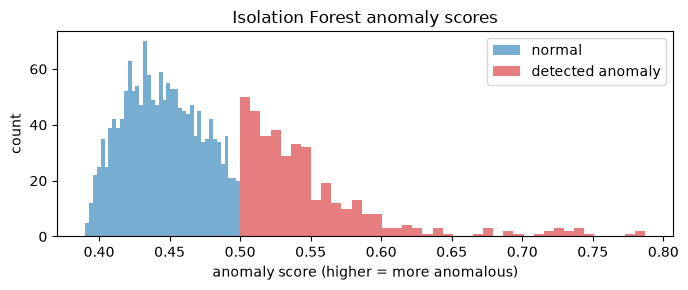

In [13]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(all_scores[~all_predictions].to_numpy(), bins=40, alpha=0.6, label="normal", color="tab:blue")
ax.hist(all_scores[all_predictions].to_numpy(), bins=40, alpha=0.6, label="detected anomaly", color="tab:red")
ax.set_xlabel("anomaly score (higher = more anomalous)")
ax.set_ylabel("count")
ax.set_title("Isolation Forest anomaly scores")
ax.legend()
plt.tight_layout()
plt.show()


In [14]:
MODELS_DIR.mkdir(exist_ok=True)
detector.save_model(DEFAULT_MODEL_FILE)
print("Model saved to", DEFAULT_MODEL_FILE)


2026-09-05 15:13:17,499 | INFO | src.ai.anomaly_detection | Saved model to E:\PhD-Blockchain-AI\models\isolation_forest_v01.joblib


Model saved to E:\PhD-Blockchain-AI\models\isolation_forest_v01.joblib


## 7. Convert selected records into transactions

Records flagged by the detector become canonical transactions via
`src/blockchain/core.py::create_transaction`. Fields: `transaction_id`,
`participant_id`, `product_id`, `order_id`, `timestamp`, `quantity`,
`transaction_status`, plus predicted-anomaly metadata. Each transaction is
stamped with its SHA-256 `data_hash`.


In [15]:
needed = ["predicted_anomaly", "anomaly_score", "participant_id", "product_id", "order_id", "timestamp", "quantity", "transaction_status"]
scored_records = scored[needed]
chain = build_blockchain_from_flags(scored_records, max_transactions=8)
print(f"Built {len(chain)} blocks carrying {sum(len(b['transactions']) for b in chain)} flagged transactions")


Built 50 blocks carrying 386 flagged transactions


In [ ]:
tx = chain[1]["transactions"][0]
print("transaction_id :", tx["transaction_id"])
print("data_hash      :", tx["data_hash"][:24] + "...")
print("stored hash    :", tx["hash"][:24] + "...")
print("matches recompute:", calculate_transaction_hash(tx) == tx["hash"])


## 8. Create blocks and build the blockchain

`create_block` batches transactions up to `MAX_TRANSACTIONS_PER_BLOCK` (8).
Every block stores `previous_block_hash` and its own `current_block_hash`,
linking the ledger from the genesis block.


In [16]:
genesis = create_genesis_block()
print("genesis block id      :", genesis["block_id"])
print("genesis previous hash :", genesis["previous_block_hash"][:16] + "...")
print("genesis current hash  :", genesis["current_block_hash"][:24] + "...")


genesis block id      : 0
genesis previous hash : 0000000000000000...
genesis current hash  : 3e6d116cabcaef6637e6c4df...


In [17]:
for block in chain[:4]:
    print(f"block_id={block['block_id']}  txs={len(block['transactions'])}  prev={block['previous_block_hash'][:12]}...  curr={block['current_block_hash'][:12]}...")


block_id=0  txs=0  prev=000000000000...  curr=541d5bcf6415...
block_id=1  txs=8  prev=541d5bcf6415...  curr=fe0b0ce7fea3...
block_id=2  txs=8  prev=fe0b0ce7fea3...  curr=32ce299fc91c...
block_id=3  txs=8  prev=32ce299fc91c...  curr=b67d5f77ece3...


## 9. Verify blockchain

`verify_chain` re-hashes every block and checks the genesis anchor plus each
inter-block link.


In [18]:
print("verify_chain(chain):", verify_chain(chain))


verify_chain(chain): True


## 10. Simulate tampering

We pretend an attacker quietly edited the `quantity` of one *sealed*
transaction without updating any hashes. The security helper returns a
deep-enough copy so the original chain stays intact for comparison.


In [20]:
target_block = chain[1]
target_tx = target_block["transactions"][0]
tampered_chain = modify_transaction_after_sealing(
    chain,
    block_id=target_block["block_id"],
    transaction_id=target_tx["transaction_id"],
    field="quantity",
    new_value=-999.0,
)

print("before :", chain[1]["transactions"][0]["quantity"])
print("after  :", tampered_chain[1]["transactions"][0]["quantity"])
print("original chain still verifies:", verify_chain(chain))


2026-09-05 15:13:54,559 | WARNING | src.security.integrity | Simulated tampering: set quantity=-999.0 on TXN-000004 (block 1); hashes left stale


before : 500.0
after  : -999.0
original chain still verifies: True


## 11. Detect tampering

`detect_tampering` re-computes transaction and block hashes and reports exactly
which block, transaction and links were affected.


In [21]:
tamper_report = detect_tampering(tampered_chain)
print(json.dumps(tamper_report, indent=2, default=str))


2026-09-05 15:14:00,149 | INFO | src.blockchain.validation | Tampering detected: 0 affected block(s) ([]), 1 tampered transaction(s), 0 broken link(s).


{
  "tampered": true,
  "tampered_blocks": [],
  "tampered_transactions": [
    "TXN-000004"
  ],
  "broken_links": [],
  "report": "Tampering detected: 0 affected block(s) ([]), 1 tampered transaction(s), 0 broken link(s)."
}


## 12. Measure execution time

The `ExecutionTimer` context manager records wall-clock time, CPU time, average
and peak CPU utilisation, and peak RSS memory - all *measured* metrics.


In [22]:
with ExecutionTimer(label="hash-1000-transactions") as timer:
    hashes = []
    for i in range(1000):
        txn = create_transaction(
            transaction_id=f"TXN-{i:07d}",
            participant_id="supplier_a",
            product_id="PROD-001",
            order_id=f"ORD-{i:07d}",
            timestamp="2024-06-01T10:00:00+00:00",
            quantity=120.0,
            transaction_status="completed",
        )
        hashes.append(calculate_transaction_hash(txn))

measurement = timer.measurement
print(json.dumps(measurement.to_dict(), indent=2))
print("First hash:", hashes[0])


2026-09-05 15:14:06,481 | INFO | src.energy.measurement | Measured hash-1000-transactions: wall=0.0218s cpu=0.0156s peak_rss=238641152 bytes


{
  "wall_time_seconds": 0.021773,
  "cpu_time_seconds": 0.015625,
  "avg_cpu_percent": 0.0,
  "peak_cpu_percent": 0.0,
  "peak_memory_rss_bytes": 238641152,
  "start_memory_rss_bytes": 238358528,
  "end_memory_rss_bytes": 238641152,
  "sample_count": 3
}
First hash: 5bb0fbc552a830a80f90b969cc768dfa64b51bb78ae7f6f7d5d5c0d79b0c04a7


## 13. Display CPU / memory information

System context is read live from the executing machine with `psutil` (all
values are measured informational data).


In [23]:
system_info = report_system_info()
for key, value in system_info.items():
    print(f"{key:24s}: {value}")


platform                : Windows-11-10.0.26200-SP0
python                  : 3.13.14
logical_cpus            : 12
physical_cpus           : 10
cpu_freq_max_mhz        : 1700
system_cpu_percent      : 43.5
process_cpu_percent     : 0.0
process_rss_bytes       : 238297088
memory_total_bytes      : 16890978304
memory_available_bytes  : 2314137600
memory_percent          : 86.3


## 14. Estimate energy (ESTIMATE, not a measurement)

Using the documented convention `Energy = Power x Time` from
`src/energy/estimation.py`, we combine the *measured* wall-time of the
workload above with a typical-TDP power model. The result is a research proxy
and is explicitly flagged as an estimate - it is **not** physical energy
consumption.


In [24]:
estimate = estimate_energy_consumption(measurement)
print(json.dumps(estimate.to_dict(), indent=2))


2026-09-05 15:14:18,671 | INFO | src.energy.estimation | Estimated energy 1.4806 J from 0.0218 s x power model 65.0/3.0 W


{
  "energy_joules_ESTIMATED": 1.480591,
  "cpu_energy_joules_ESTIMATED": 1.415271,
  "ram_energy_joules_ESTIMATED": 0.06532,
  "wall_time_seconds_measured": 0.021773,
  "power_model": "Typical TDP convention (not measured): 65.0 W CPU + 3.0 W RAM",
  "is_estimated": true
}


## 15. Save results

The full run summary (source, label kind, metrics, measurement, tamper-detection
verdict, counts) is written as a self-describing JSON report under `results/`.


In [ ]:
payload = {
    "stage": "prototype-v0.1",
    "seed": GLOBAL_SEED,
    "data_source": source_used,
    "label_kind": label_kind,
    "n_raw_rows": int(len(raw_df)),
    "n_processed_rows": int(len(processed_df)),
    "n_feature_rows": int(features.shape[0]),
    "n_features": int(features.shape[1]),
    "n_flagged_anomalies": int(n_flagged),
    "n_blocks": len(chain),
    "n_chain_transactions": sum(len(b["transactions"]) for b in chain),
    "chain_verifies_post_build": bool(verify_chain(chain)),
    "tampering_detected_after_simulation": bool(tamper_report["tampered"]),
    "measurement": measurement.to_dict(),
    "system_info": system_info,
    "energy_estimate_ESTIMATED": estimate.to_dict(),
    "label_note": "controlled/synthetic or Kaggle Late_delivery_risk labels - never cybersecurity labels",
}
saved_path = save_experiment_results(payload, output_path=DEFAULT_RESULTS_FILE)
print("Saved:", saved_path)


2026-09-05 15:14:25,077 | INFO | src.evaluation.reporting | Saved experiment results to E:\PhD-Blockchain-AI\results\prototype_v01_results.json


Saved: E:\PhD-Blockchain-AI\results\prototype_v01_results.json


: 

## Summary

Prototype V0.1 delivers the full, reproducible reference workflow:

- source-aware data loading (local cache / real Kaggle DataCo table / synthetic
  fallback) with honest label provenance (`controlled_synthetic`,
  `natural_late_delivery_risk`, or `none`),
- preprocessing + feature engineering,
- baseline Isolation Forest anomaly detection with label-optional metrics,
- a lightweight, hash-chained simulated blockchain with creation → verification → tamper detection,
- execution-time, CPU and memory measurement with a clearly separated energy *estimate*,
- a JSON experiment report saved under `results/`.

Planned later phases (NSGA-II/MOPSO/PSO feature optimisation, deep learning,
PostgreSQL/FastAPI, real Ethereum/Hyperledger, 1M-transaction experiments) are
intentionally not implemented yet.
